# 06. Imbalanced Learning

This notebook focuses on addressing class imbalance in credit card fraud detection using re-sampling strategies (Random Oversampling and SMOTE) and evaluating their impact on model performance.


## 1. Objective

The objective of this notebook is to investigate whether handling class imbalance improves fraud detection performance. Different sampling techniques will be applied to the training data, and their impact on the baseline model will be evaluated using the same test dataset.

## 2. Import Libraries

Import required data handling, visualization, imbalanced-learn, and scikit-learn evaluation modules.


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

## 3. Load Preprocessed Data

Load partitioned `X_train`, `y_train`, `X_test`, and `y_test` datasets generated in `04_Preprocessing.ipynb`.


In [3]:
X_train = pd.read_csv("D:\Fraud Detection\data\processed\X_train.csv")

X_test = pd.read_csv("D:\Fraud Detection\data\processed\X_test.csv")

y_train = pd.read_csv("D:\Fraud Detection\data\processed\y_train.csv").squeeze()

y_test = pd.read_csv("D:\Fraud Detection\data\processed\y_test.csv").squeeze()

<>:1: SyntaxWarning: invalid escape sequence '\F'
<>:3: SyntaxWarning: invalid escape sequence '\F'
<>:5: SyntaxWarning: invalid escape sequence '\F'
<>:7: SyntaxWarning: invalid escape sequence '\F'
<>:1: SyntaxWarning: invalid escape sequence '\F'
<>:3: SyntaxWarning: invalid escape sequence '\F'
<>:5: SyntaxWarning: invalid escape sequence '\F'
<>:7: SyntaxWarning: invalid escape sequence '\F'
C:\Users\anujj\AppData\Local\Temp\ipykernel_11112\654208385.py:1: SyntaxWarning: invalid escape sequence '\F'
  X_train = pd.read_csv("D:\Fraud Detection\data\processed\X_train.csv")
C:\Users\anujj\AppData\Local\Temp\ipykernel_11112\654208385.py:3: SyntaxWarning: invalid escape sequence '\F'
  X_test = pd.read_csv("D:\Fraud Detection\data\processed\X_test.csv")
C:\Users\anujj\AppData\Local\Temp\ipykernel_11112\654208385.py:5: SyntaxWarning: invalid escape sequence '\F'
  y_train = pd.read_csv("D:\Fraud Detection\data\processed\y_train.csv").squeeze()
C:\Users\anujj\AppData\Local\Temp\ipykernel

## 4. Verify Original Class Distribution

Inspect class distributions and fraud prevalence ratios in the un-resampled training partition.


In [4]:
print(y_train.value_counts())

print(y_train.value_counts(normalize=True) * 100)

Class
0    226602
1       378
Name: count, dtype: int64
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64


## 5. Apply Random Oversampling

Perform Random Oversampling on the training data to balance class representation.


In [5]:
ros = RandomOverSampler(random_state=42)

X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

In [6]:
y_train_ros.shape

(453204,)

In [7]:
X_train_ros.shape

(453204, 30)

In [8]:
y_train_ros.value_counts()

Class
0    226602
1    226602
Name: count, dtype: int64

In [9]:
print(y_train_ros.value_counts())

print(X_train_ros.shape)

print(y_train_ros.shape)

Class
0    226602
1    226602
Name: count, dtype: int64
(453204, 30)
(453204,)


Random Oversampling successfully balanced the training dataset by duplicating minority class (fraud) observations until both classes contained 226,602 samples each. The training dataset increased from 226,980 to 453,204 observations, while the feature count remained unchanged at 30. The test dataset was intentionally left untouched to preserve a realistic evaluation environment.

## 6. Train Random Forest

Train a Random Forest classifier on the Random Oversampled training dataset.


In [10]:
rf_ros_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_ros_model.fit(X_train_ros, y_train_ros)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## 7. Evaluate Model

Evaluate the Random Oversampled model on the un-resampled test dataset across key metrics (Precision, Recall, PR-AUC, ROC-AUC, F1 Score).


In [11]:
rf_ros_y_pred = rf_ros_model.predict(X_test)
rf_ros_y_prob = rf_ros_model.predict_proba(X_test)

In [12]:
rf_ros_cm = confusion_matrix(y_test, rf_ros_y_pred)
print(rf_ros_cm)

[[56648     3]
 [   26    69]]


In [14]:
# Metrics
rf_ros_accuracy = accuracy_score(y_test, rf_ros_y_pred)
rf_ros_precision = precision_score(y_test, rf_ros_y_pred)
rf_ros_recall = recall_score(y_test, rf_ros_y_pred)
rf_ros_f1 = f1_score(y_test, rf_ros_y_pred)
rf_ros_roc_auc = roc_auc_score(y_test, rf_ros_y_prob[:, 1])
rf_ros_pr_auc = average_precision_score(y_test, rf_ros_y_prob[:, 1])

In [15]:
print(f"Accuracy : {rf_ros_accuracy:.4f}")
print(f"Precision: {rf_ros_precision:.4f}")
print(f"Recall   : {rf_ros_recall:.4f}")
print(f"F1 Score : {rf_ros_f1:.4f}")
print(f"ROC-AUC  : {rf_ros_roc_auc:.4f}")
print(f"PR-AUC   : {rf_ros_pr_auc:.4f}")

Accuracy : 0.9995
Precision: 0.9583
Recall   : 0.7263
F1 Score : 0.8263
ROC-AUC  : 0.9292
PR-AUC   : 0.8023


In [16]:
print(classification_report(y_test, rf_ros_y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



A Random Forest classifier was trained on a Random Oversampled version of the training dataset. Compared with the baseline model, Random Oversampling did not improve the number of fraudulent transactions detected, as Recall remained unchanged at 72.63%. The technique introduced one additional false positive, resulting in a slight decrease in Precision and F1-score. Although ROC-AUC and PR-AUC showed modest improvements, the overall classification performance at the default decision threshold remained largely unchanged. Therefore, Random Oversampling did not provide a significant practical advantage for this dataset.

## 8. Apply SMOTE

Perform Synthetic Minority Over-sampling Technique (SMOTE) on the training dataset.


In [17]:
smote  = SMOTE(random_state=42)

In [18]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [19]:
print(y_train_smote.value_counts())


print(y_train_smote.value_counts(normalize=True) * 100)


print(X_train_smote.shape)

print(y_train_smote.shape)

Class
0    226602
1    226602
Name: count, dtype: int64
Class
0    50.0
1    50.0
Name: proportion, dtype: float64
(453204, 30)
(453204,)


## 9. Train Random Forest

Train a Random Forest classifier on the SMOTE-resampled training dataset.


In [21]:

rf_smote_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [22]:
rf_smote_model.fit(X_train_smote, y_train_smote)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [23]:
rf_smote_y_pred = rf_smote_model.predict(X_test)

rf_smote_y_prob = rf_smote_model.predict_proba(X_test)

## 10. Evaluate Model


In [24]:
rf_smote_cm = confusion_matrix(y_test, rf_smote_y_pred)
print(rf_smote_cm)

[[56644     7]
 [   21    74]]


In [25]:
rf_smote_accuracy = accuracy_score(y_test, rf_smote_y_pred)
rf_smote_precision = precision_score(y_test, rf_smote_y_pred)
rf_smote_recall = recall_score(y_test, rf_smote_y_pred)
rf_smote_f1 = f1_score(y_test, rf_smote_y_pred)

rf_smote_roc_auc = roc_auc_score(
    y_test,
    rf_smote_y_prob[:, 1]
)

rf_smote_pr_auc = average_precision_score(
    y_test,
    rf_smote_y_prob[:, 1]
)

In [26]:
print(f"Accuracy : {rf_smote_accuracy:.4f}")
print(f"Precision: {rf_smote_precision:.4f}")
print(f"Recall   : {rf_smote_recall:.4f}")
print(f"F1 Score : {rf_smote_f1:.4f}")
print(f"ROC-AUC  : {rf_smote_roc_auc:.4f}")
print(f"PR-AUC   : {rf_smote_pr_auc:.4f}")

print(classification_report(y_test, rf_smote_y_pred))

Accuracy : 0.9995
Precision: 0.9136
Recall   : 0.7789
F1 Score : 0.8409
ROC-AUC  : 0.9591
PR-AUC   : 0.8078
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.78      0.84        95

    accuracy                           1.00     56746
   macro avg       0.96      0.89      0.92     56746
weighted avg       1.00      1.00      1.00     56746



Applying SMOTE improved the Random Forest model's ability to detect fraudulent transactions. Recall increased from 72.63% to 77.89%, reducing the number of missed fraud cases from 26 to 21. Although Precision decreased from 97.18% to 91.36% due to an increase in false positives, the improvements in F1-score, ROC-AUC, and PR-AUC indicate a stronger overall model for fraud detection. Given the business objective of minimizing undetected fraud, the SMOTE-based Random Forest model provides the best trade-off among the evaluated sampling strategies.

## 11. Compare Sampling Techniques

Compare baseline Random Forest performance against Random Oversampling and SMOTE performance using summary tables.


In [31]:
baseline_results = pd.read_csv(
    "../reports/baseline_model_results.csv"
)
baseline_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.999101,0.843750,0.568421,0.679245,0.957260,0.690032
1,Decision Tree,0.999048,0.720430,0.705263,0.712766,0.852402,0.508586
2,Random Forest,0.999507,0.971831,0.726316,0.831325,0.923948,0.787576
3,XGBoost,0.999242,0.817073,0.705263,0.757062,0.847453,0.664855


In [32]:
baseline_rf = baseline_results[
    baseline_results["Model"] == "Random Forest"
]

In [34]:
sampling_results = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Random Forest + Random Oversampling",
        "Random Forest + SMOTE"
    ],
    "Accuracy": [
        baseline_rf["Accuracy"].values[0],
        rf_ros_accuracy,
        rf_smote_accuracy
    ],
    "Precision": [
        baseline_rf["Precision"].values[0],
        rf_ros_precision,
        rf_smote_precision
    ],
    "Recall": [
        baseline_rf["Recall"].values[0],
        rf_ros_recall,
        rf_smote_recall
    ],
    "F1 Score": [
        baseline_rf["F1 Score"].values[0],
        rf_ros_f1,
        rf_smote_f1
    ],
    "ROC-AUC": [
        baseline_rf["ROC-AUC"].values[0],
        rf_ros_roc_auc,
        rf_smote_roc_auc
    ],
    "PR-AUC": [
        baseline_rf["PR-AUC"].values[0],
        rf_ros_pr_auc,
        rf_smote_pr_auc
    ]
})

sampling_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Baseline Random Forest,0.999507,0.971831,0.726316,0.831325,0.923948,0.787576
1,Random Forest + Random Oversampling,0.999489,0.958333,0.726316,0.826347,0.929159,0.802261
2,Random Forest + SMOTE,0.999507,0.913580,0.778947,0.840909,0.959076,0.807759


In [36]:
sampling_results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
2,Random Forest + SMOTE,0.999507,0.913580,0.778947,0.840909,0.959076,0.807759
0,Baseline Random Forest,0.999507,0.971831,0.726316,0.831325,0.923948,0.787576
1,Random Forest + Random Oversampling,0.999489,0.958333,0.726316,0.826347,0.929159,0.802261


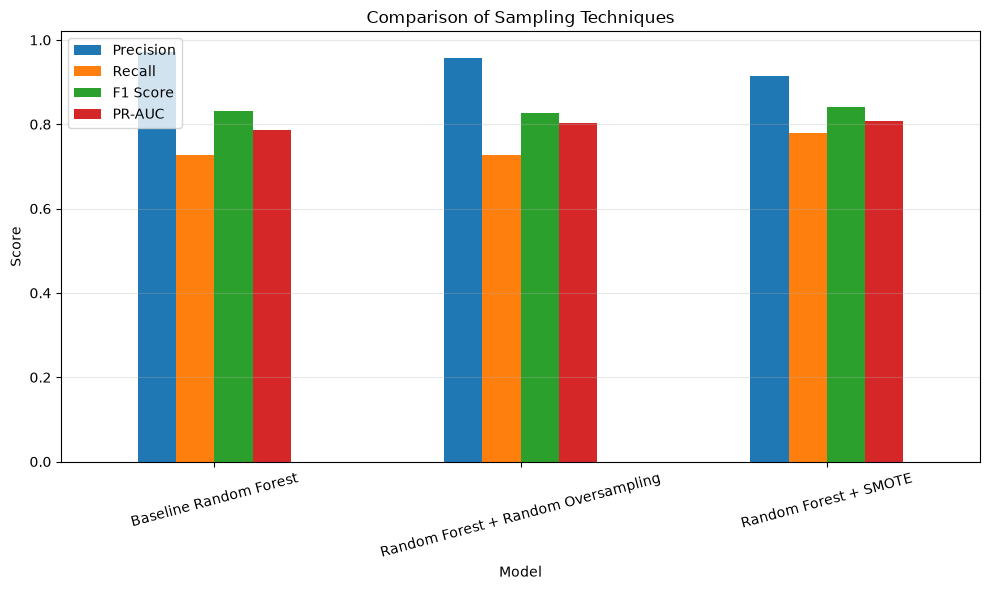

In [41]:
metrics = ["Precision", "Recall", "F1 Score", "PR-AUC"]

sampling_results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Sampling Techniques")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Save Results



In [35]:
sampling_results.to_csv(
    "../reports/rf_comparission_results.csv",
    index=False
)

In [42]:
import joblib

joblib.dump(
    rf_smote_model,
    "../models/random_forest_smote.pkl"
)

print("SMOTE Random Forest model saved successfully.")

SMOTE Random Forest model saved successfully.


In [44]:
joblib.dump(
    rf_ros_model,
    "../models/random_forest_random_oversampling.pkl"
)


['../models/random_forest_random_oversampling.pkl']

In [45]:
import os

print("Models")
print(os.listdir("../models"))

print("\nReports")
print(os.listdir("../reports"))

Models
['decision_tree.pkl', 'final_model', 'logistic_regression.pkl', 'random_forest.pkl', 'random_forest_random_oversampling.pkl', 'random_forest_smote.pkl', 'scaler_amount.joblib', 'scaler_time.joblib', 'trained_models', 'xgboost.pkl']

Reports
['baseline_model_results.csv', 'confusion_matrices', 'feature_importance', 'figures', 'model_results', 'pr_curves', 'rf_comparission_results.csv', 'roc_curves']


## 13. Conclusion



Three training strategies were compared using the same Random Forest model and identical evaluation metrics. Random Oversampling produced performance similar to the baseline model, indicating that duplicating minority-class observations alone did not significantly improve fraud detection. In contrast, SMOTE increased Recall, F1-score, ROC-AUC, and PR-AUC by generating synthetic minority-class samples. Although Precision decreased slightly, the overall improvement in fraud detection performance makes SMOTE the preferred sampling strategy for this project.